In [1]:
import pandas as pd
import numpy as np
import nltk
import plotly.io as pio
import matplotlib.pyplot as plt
import pickle
import os

from nltk.corpus import stopwords
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from gensim.corpora import Dictionary
from gensim.models import CoherenceModel

nltk.download('stopwords')
stop_words_id = stopwords.words('indonesian')

os.makedirs('visualisasi', exist_ok=True)
os.makedirs('model', exist_ok=True)

print("Import selesai.")

c:\skripsi\model\BERTopic_skripsi\BERTopic_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Import selesai.


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
df = pd.read_csv('data_BERTOPIC/data_BERTopic.csv')
docs = df['final_bertopic'].tolist()
print(f"Jumlah dokumen: {len(docs)}")
print(f"Contoh dokumen pertama: {docs[0]}")

Jumlah dokumen: 2116
Contoh dokumen pertama: korps pemberantasan tindak pidana korupsi kortas tipikor polri mengungkap kasus dugaan korupsi pada ditjen energi baru terbarukan dan konservasi energi ebtke kementerian esdm terkait pengadaan penerangan jalan umum tenaga surya pjuts polri menyebut kerugian dalam kasus ini rp dirtindak kortastipidkor brigjen totok suharyanto mengatakan ada tiga orang yang ditetapkan sebagai tersangka dalam kasus tersebut ketiga tersangka ialah as selaku mantan inspektur jenderal kementerian esdm ri periode hs selaku mantan sekretaris ditjen ebtke sekaligus kpa dan l selaku mantan direktur operasional pt len industri totok mengatakan kasus ini terjadi pada saat itu katanya ditjen ebtke mengadakan lelang pemasangan pjuts sebanyak unit di tujuh provinsi sebelum pelaksanaan lelang tersangka as diduga melakukan kongkalikong dengan hs dan l untuk memenangkan pt len industri caranya adalah dengan melakukan perubahan spesifikasi dan pemaketan yang semula paket kecil

In [3]:
embedding_model = SentenceTransformer('distiluse-base-multilingual-cased')
print("Embedding model siap.")

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 866.09it/s, Materializing param=transformer.layer.5.sa_layer_norm.weight]   


Embedding model siap.


In [4]:
umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric='cosine',
    random_state=42
)

hdbscan_model = HDBSCAN(
    min_cluster_size=10,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)

vectorizer_model = CountVectorizer(
    stop_words=stop_words_id,
    ngram_range=(1, 2)
)

topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    calculate_probabilities=True,
    verbose=True
)

print("Konfigurasi model selesai.")

Konfigurasi model selesai.


In [5]:
topics, probs = topic_model.fit_transform(docs)
print(f"Training selesai.")
print(f"Jumlah topik terbentuk: {len(topic_model.get_topic_info()) - 1}")

2026-04-06 15:06:27,171 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 67/67 [00:32<00:00,  2.03it/s]
2026-04-06 15:07:00,167 - BERTopic - Embedding - Completed ✓
2026-04-06 15:07:00,168 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-06 15:07:13,540 - BERTopic - Dimensionality - Completed ✓
2026-04-06 15:07:13,542 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-06 15:07:13,702 - BERTopic - Cluster - Completed ✓
2026-04-06 15:07:13,711 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-06 15:07:14,205 - BERTopic - Representation - Completed ✓


Training selesai.
Jumlah topik terbentuk: 35


In [6]:
topic_info = topic_model.get_topic_info()
print(topic_info.head(10))

   Topic  Count                                         Name  \
0     -1    912                -1_etanol_bbm_bahan_pertamina   
1      0    104           0_etanol_bahlil etanol_bahlil_pake   
2      1     89                   1_air_etanol_bensin_tangki   
3      2     70  2_campur etanol_campur_bensin campur_bensin   
4      3     69               3_swasta_etanol_pertamina_spbu   
5      4     69                         4_etanol_bbm_pake_si   
6      5     58                       5_etanol_si_bau_isinya   
7      6     51    6_bbm campur_bbm_bbm etanol_campur etanol   
8      7     49                   7_harga_mahal_murah_etanol   
9      8     42             8_indonesia_brasil_bahlil_etanol   

                                      Representation  \
0  [etanol, bbm, bahan, pertamina, bahlil, bensin...   
1  [etanol, bahlil etanol, bahlil, pake, bau etan...   
2  [air, etanol, bensin, tangki, campur, bbm, per...   
3  [campur etanol, campur, bensin campur, bensin,...   
4  [swasta, eta

In [7]:
print("Kata kunci per topik:\n")
for topic_id in sorted(set(topics)):
    if topic_id != -1:
        words = topic_model.get_topic(topic_id)
        print(f"Topik {topic_id}: {[w for w, _ in words[:10]]}")

Kata kunci per topik:

Topik 0: ['etanol', 'bahlil etanol', 'bahlil', 'pake', 'bau etanol', 'bahenol', 'etanol bahlil', 'bau', 'bahenol bahlil', 'pake etanol']
Topik 1: ['air', 'etanol', 'bensin', 'tangki', 'campur', 'bbm', 'pertalite', 'menyerap air', 'higroskopis', 'menyerap']
Topik 2: ['campur etanol', 'campur', 'bensin campur', 'bensin', 'etanol', 'gara', 'bensin etanol', 'bahan bakar', 'bahan', 'bakar']
Topik 3: ['swasta', 'etanol', 'pertamina', 'spbu', 'spbu swasta', 'kandungan', 'bbm', 'kandungan etanol', 'base', 'base fuel']
Topik 4: ['etanol', 'bbm', 'pake', 'si', 'bbm etanol', 'pake etanol', 'bikin', 'nnti', 'etanol bikin', 'rasul']
Topik 5: ['etanol', 'si', 'bau', 'isinya', 'si etanol', 'bau etanol', 'orang etanol', 'pls', 'bahlul', 'etanol etanolnya']
Topik 6: ['bbm campur', 'bbm', 'bbm etanol', 'campur etanol', 'etanol', 'campur', 'ri', 'ramai', 'investor', 'program bbm']
Topik 7: ['harga', 'mahal', 'murah', 'etanol', 'bbm', 'kalo', 'harga etanol', 'biaya', 'liter', 'murni

C_v Coherence Score: 0.5037


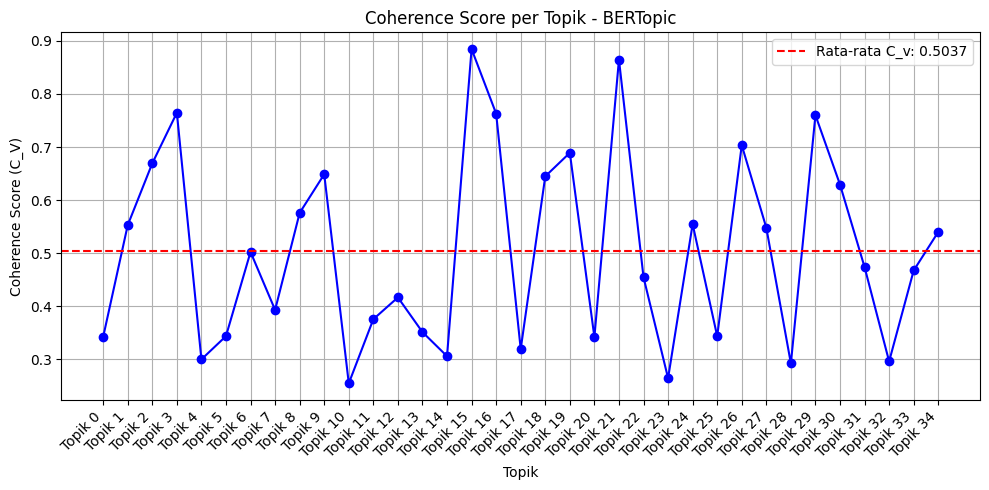

In [9]:
tokenized_docs = [doc.split() for doc in docs]
dictionary = Dictionary(tokenized_docs)
corpus = [dictionary.doc2bow(tokens) for tokens in tokenized_docs]

topics_words = []
topic_ids = []
for topic_id in sorted(set(topics)):
    if topic_id != -1:
        words = [word for word, _ in topic_model.get_topic(topic_id)[:10]]
        topics_words.append(words)
        topic_ids.append(topic_id)

if topics_words:
    cv_model = CoherenceModel(
        topics=topics_words,
        texts=tokenized_docs,
        dictionary=dictionary,
        coherence='c_v'
    )
    cv_score = cv_model.get_coherence()
    cv_per_topic = cv_model.get_coherence_per_topic()
    
    print(f"C_v Coherence Score: {cv_score:.4f}")

    plt.figure(figsize=(10, 5))
    plt.plot(
        [f"Topik {t}" for t in topic_ids],
        cv_per_topic,
        marker='o',
        color='b'
    )
    plt.axhline(y=cv_score, color='red', linestyle='--', label=f'Rata-rata C_v: {cv_score:.4f}')
    plt.xlabel('Topik')
    plt.ylabel('Coherence Score (C_V)')
    plt.title('Coherence Score per Topik - BERTopic')
    plt.xticks(rotation=45, ha='right')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('visualisasi/coherence_score_bertopic.png', dpi=150)
    plt.show()
else:
    print("Tidak ada topik yang terbentuk.")

In [10]:
def topic_diversity(topic_model, topics, top_n=10):
    topics_words = []
    for topic_id in set(topics):
        if topic_id != -1:
            words = [word for word, _ in topic_model.get_topic(topic_id)[:top_n]]
            topics_words.append(words)

    all_words = [word for topic in topics_words for word in topic]
    unique_words = set(all_words)
    diversity = len(unique_words) / len(all_words) if all_words else 0
    return diversity

td_score = topic_diversity(topic_model, topics)
print(f"Topic Diversity: {td_score:.4f}")

Topic Diversity: 0.6914


In [11]:
# Sebaran topik 2D
fig_topics = topic_model.visualize_topics()
pio.write_html(fig_topics, 'visualisasi/topics.html')

# Kata kunci per topik
fig_barchart = topic_model.visualize_barchart(top_n_topics=10, n_words=10)
pio.write_html(fig_barchart, 'visualisasi/barchart_topik.html')

# Kesamaan antar topik
fig_heatmap = topic_model.visualize_heatmap(top_n_topics=10)
pio.write_html(fig_heatmap, 'visualisasi/heatmap_topik.html')

# Hierarki topik
fig_hierarchy = topic_model.visualize_hierarchy(top_n_topics=10)
pio.write_html(fig_hierarchy, 'visualisasi/hierarchy_topik.html')

print("Semua visualisasi disimpan.")

Semua visualisasi disimpan.


In [12]:
import os
os.makedirs('model', exist_ok=True)

# Simpan tanpa embedding model (lebih aman)
topic_model.save(
    "model/bertopic_model",
    serialization="safetensors",
    save_embedding_model=False,
    save_ctfidf=True
)

# Load kembali dengan embedding model didefinisikan ulang
loaded_model = BERTopic.load(
    "model/bertopic_model",
    embedding_model=embedding_model
)

print("Model berhasil disimpan dan diverifikasi.")

2026-04-06 15:08:31,066 - BERTopic - WARNING: You are saving a BERTopic model without explicitly defining an embedding model.If you are using a sentence-transformers model or a HuggingFace model supportedby sentence-transformers, please save the model by using a pointer towards that model.For example, `save_embedding_model='sentence-transformers/all-mpnet-base-v2'`


Model berhasil disimpan dan diverifikasi.
